# Estudio de ablación y selección de variables para clustering

Este notebook analiza qué columnas aportan información útil a la segmentación de H&M e Instacart. Mantiene el estudio condicionado sobre la base RFM/RFA y añade una ablación de sus componentes, configuraciones con cero, una o dos variables básicas y una selección acumulativa no condicionada. Así se comprueba empíricamente si las tres variables teóricas son realmente necesarias.

## Metodología

Para reducir el coste computacional se utiliza MiniBatch K-Means como modelo de referencia sobre una muestra reproducible. Cada subconjunto se evalúa para `k=2..6` y tres semillas. La comparación combina silhouette y Calinski-Harabasz —mayor es mejor— con Davies-Bouldin —menor es mejor—. Los rankings se calculan dentro de cada dataset y valor de `k`, de modo que solo se comparan subconjuntos bajo las mismas condiciones.

In [1]:
from pathlib import Path
from itertools import combinations
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

RANDOM_SEEDS = [42, 123, 2026]
K_VALUES = range(2, 7)
SAMPLE_SIZE = 50_000
SILHOUETTE_SAMPLE = 10_000
RESULTS_DIR = Path("../../results/feature_selection")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Configuración de los datasets

In [2]:
DATASETS = {
    "hym": {
        "scaled": "../../scaled_data/hym_scaled.csv",
        "simple": "../../simple_datasets/hym_model_simple.csv",
        "extended": "../../extended_datasets/hym_model_extended.csv",
        "id_col": "customer_id",
    },
    "instacart": {
        "scaled": "../../scaled_data/instacart_scaled.csv",
        "simple": "../../simple_datasets/instacart_model_simple.csv",
        "extended": "../../extended_datasets/instacart_model_extended.csv",
        "id_col": "user_id",
    },
}

## Funciones de evaluación

In [3]:
def cargar_datos(config):
    columnas_simple = list(pd.read_csv(config["simple"], nrows=0).columns)
    columnas_extended = list(pd.read_csv(config["extended"], nrows=0).columns)
    df_scaled = pd.read_csv(config["scaled"])
    id_col = config["id_col"]

    simples = [c for c in columnas_simple if c in df_scaled.columns and c != id_col]
    extendidas = [c for c in columnas_extended if c in df_scaled.columns and c != id_col]
    adicionales = [c for c in extendidas if c not in simples]
    muestra = df_scaled[extendidas].sample(
        n=min(SAMPLE_SIZE, len(df_scaled)), random_state=42
    ).reset_index(drop=True)
    return muestra, simples, extendidas, adicionales

def construir_subsets_iniciales(simples, extendidas, adicionales):
    """Crea candidatos de referencia y ablación sin repetir columnas."""
    subsets = {}
    firmas = set()

    def agregar(nombre, columnas):
        columnas = list(dict.fromkeys(columnas))
        firma = tuple(sorted(columnas))
        if columnas and firma not in firmas:
            subsets[nombre] = columnas
            firmas.add(firma)

    agregar("base completa", simples)
    agregar("extended completo", extendidas)

    for columna in extendidas:
        agregar(f"individual: {columna}", [columna])
    for pareja in combinations(simples, 2):
        agregar(f"pareja base: {' + '.join(pareja)}", pareja)

    for columna in adicionales:
        agregar(f"base + {columna}", simples + [columna])

    for columna in simples:
        agregar(f"base sin {columna}", [c for c in simples if c != columna])
        agregar(f"extended sin {columna}", [c for c in extendidas if c != columna])

    agregar("solo adicionales", adicionales)
    for columna in simples:
        agregar(f"adicionales + {columna}", adicionales + [columna])
    for pareja in combinations(simples, 2):
        agregar(f"adicionales + {' + '.join(pareja)}", adicionales + list(pareja))

    return subsets

def evaluar_subset(X, dataset, subset_name, columns):
    filas = []
    datos = X[columns]
    for k in K_VALUES:
        for seed in RANDOM_SEEDS:
            inicio = time.time()
            modelo = MiniBatchKMeans(
                n_clusters=k, n_init=10, batch_size=4096, random_state=seed
            )
            labels = modelo.fit_predict(datos)
            filas.append({
                "dataset": dataset,
                "subset": subset_name,
                "columns": " | ".join(columns),
                "n_features": len(columns),
                "k": k,
                "seed": seed,
                "silhouette": silhouette_score(
                    datos, labels,
                    sample_size=min(SILHOUETTE_SAMPLE, len(datos)),
                    random_state=seed,
                ),
                "calinski_harabasz": calinski_harabasz_score(datos, labels),
                "davies_bouldin": davies_bouldin_score(datos, labels),
                "inertia": modelo.inertia_,
                "time_seconds": time.time() - inicio,
            })
    return filas

def puntuar(resultados):
    resumen = (
        resultados.groupby(["dataset", "subset", "columns", "n_features", "k"], as_index=False)
        .agg(
            silhouette=("silhouette", "mean"),
            silhouette_std=("silhouette", "std"),
            calinski_harabasz=("calinski_harabasz", "mean"),
            davies_bouldin=("davies_bouldin", "mean"),
            time_seconds=("time_seconds", "mean"),
        )
    )
    grupos = resumen.groupby(["dataset", "k"])
    resumen["rank_silhouette"] = grupos["silhouette"].rank(ascending=False)
    resumen["rank_calinski"] = grupos["calinski_harabasz"].rank(ascending=False)
    resumen["rank_davies"] = grupos["davies_bouldin"].rank(ascending=True)
    resumen["rank_medio"] = resumen[[
        "rank_silhouette", "rank_calinski", "rank_davies"
    ]].mean(axis=1)
    tamano = grupos["subset"].transform("size")
    resumen["score"] = (
        100 * (1 - (resumen["rank_medio"] - 1) / (tamano - 1).clip(lower=1))
    ).round(2)
    return resumen

## Evaluación inicial y estudio de ablación

Se comparan la base RFM/RFA, el conjunto extendido, cada variable aislada, las parejas básicas y configuraciones con cero, una, dos o las tres variables básicas.

In [4]:
resultados_iniciales = []
informacion_datasets = {}

for dataset, config in DATASETS.items():
    muestra, simples, extendidas, adicionales = cargar_datos(config)
    subsets = construir_subsets_iniciales(simples, extendidas, adicionales)
    informacion_datasets[dataset] = (
        muestra, simples, extendidas, adicionales, subsets
    )
    for nombre, columnas in subsets.items():
        print(f"Evaluando {dataset}: {nombre}")
        resultados_iniciales.extend(
            evaluar_subset(muestra, dataset, nombre, columnas)
        )

resultados_iniciales = pd.DataFrame(resultados_iniciales)
resumen_inicial = puntuar(resultados_iniciales)
display(resumen_inicial.head())

Evaluando hym: base completa


Evaluando hym: extended completo


Evaluando hym: individual: recency


Evaluando hym: individual: frequency


Evaluando hym: individual: monetary


...

Evaluando instacart: solo adicionales


Evaluando instacart: adicionales + recency


Evaluando instacart: adicionales + frequency


Evaluando instacart: adicionales + avg_basket_size


,dataset,subset,columns,n_features,k,silhouette,silhouette_std,calinski_harabasz,davies_bouldin,time_seconds,rank_silhouette,rank_calinski,rank_davies,rank_medio,score
0,hym,adicionales + frequency,avg_basket_size | std_basket_size | avg_price ...,14,2,0.366307,0.002883,37413.351701,1.103615,1.161435,35.0,37.0,37.0,36.333333,11.67
1,hym,adicionales + frequency,avg_basket_size | std_basket_size | avg_price ...,14,3,0.252231,0.004155,25911.860298,1.527625,1.302731,36.0,37.0,39.0,37.333333,9.17
2,hym,adicionales + frequency,avg_basket_size | std_basket_size | avg_price ...,14,4,0.203038,0.012501,20816.432030,1.733900,1.220733,39.0,37.0,37.0,37.666667,8.33
3,hym,adicionales + frequency,avg_basket_size | std_basket_size | avg_price ...,14,5,0.204783,0.018463,18359.597320,1.670870,1.203604,35.0,35.0,34.0,34.666667,15.83
4,hym,adicionales + frequency,avg_basket_size | std_basket_size | avg_price ...,14,6,0.184662,0.027899,15981.936513,1.728483,1.262346,35.0,35.0,35.0,35.000000,15.00


## Construcción de combinaciones acumulativas

Se construyen dos recorridos: uno condicionado que conserva RFM/RFA y otro libre que parte de la variable con mejor resultado individual. Los subconjuntos con columnas equivalentes no se evalúan dos veces.

In [5]:
resultados_acumulativos = []

for dataset, (muestra, simples, extendidas, adicionales, subsets_iniciales) in informacion_datasets.items():
    firmas_evaluadas = {tuple(sorted(cols)) for cols in subsets_iniciales.values()}

    ranking_adicionales = (
        resumen_inicial.loc[
            (resumen_inicial["dataset"] == dataset)
            & resumen_inicial["subset"].str.startswith("base + ")
        ]
        .groupby("subset")["score"].mean()
        .sort_values(ascending=False)
    )
    orden = [nombre.replace("base + ", "") for nombre in ranking_adicionales.index]
    columnas = simples.copy()
    for posicion, columna in enumerate(orden, start=1):
        columnas = columnas + [columna]
        firma = tuple(sorted(columnas))
        if firma not in firmas_evaluadas:
            nombre = f"acumulativo condicionado {posicion}"
            print(f"Evaluando {dataset}: {nombre} ({columna})")
            resultados_acumulativos.extend(
                evaluar_subset(muestra, dataset, nombre, columnas.copy())
            )
            firmas_evaluadas.add(firma)

    ranking_individual = (
        resumen_inicial.loc[
            (resumen_inicial["dataset"] == dataset)
            & resumen_inicial["subset"].str.startswith("individual: ")
        ]
        .groupby("subset")["score"].mean()
        .sort_values(ascending=False)
    )
    orden_libre = [
        nombre.replace("individual: ", "")
        for nombre in ranking_individual.index
    ]
    columnas_libres = []
    for posicion, columna in enumerate(orden_libre, start=1):
        columnas_libres.append(columna)
        firma = tuple(sorted(columnas_libres))
        if firma not in firmas_evaluadas:
            nombre = f"acumulativo libre {posicion}"
            print(f"Evaluando {dataset}: {nombre} ({columna})")
            resultados_acumulativos.extend(
                evaluar_subset(
                    muestra, dataset, nombre, columnas_libres.copy()
                )
            )
            firmas_evaluadas.add(firma)

resultados_acumulativos = pd.DataFrame(resultados_acumulativos)
resultados_completos = pd.concat(
    [resultados_iniciales, resultados_acumulativos], ignore_index=True
)
resumen_completo = puntuar(resultados_completos)

Evaluando hym: acumulativo condicionado 2 (avg_days_between_purchases)


Evaluando hym: acumulativo condicionado 3 (unique_articles)


Evaluando hym: acumulativo condicionado 4 (unique_product_types)


Evaluando hym: acumulativo condicionado 5 (unique_garment_groups)


Evaluando hym: acumulativo condicionado 6 (unique_sections)


...

Evaluando instacart: acumulativo libre 5 (unique_departments)


Evaluando instacart: acumulativo libre 6 (reorder_ratio)


Evaluando instacart: acumulativo libre 7 (product_variety_ratio)


Evaluando instacart: acumulativo libre 8 (unique_aisles)


Evaluando instacart: acumulativo libre 9 (avg_basket_size)


## Variables recomendadas

In [6]:
ranking_subsets = (
    resumen_completo.groupby(
        ["dataset", "subset", "columns", "n_features"], as_index=False
    )
    .agg(
        score=("score", "mean"),
        score_std=("score", "std"),
        silhouette=("silhouette", "mean"),
        silhouette_std=("silhouette_std", "mean"),
        calinski_harabasz=("calinski_harabasz", "mean"),
        davies_bouldin=("davies_bouldin", "mean"),
        time_seconds=("time_seconds", "mean"),
    )
    .sort_values(["dataset", "score"], ascending=[True, False])
)

# Las configuraciones de 1-2 variables se conservan como diagnóstico de
# ablación, pero no son perfiles multivariables suficientemente ricos para
# convertirse en la recomendación final.
MIN_FEATURES_RECOMMENDATION = 3
ranking_candidatos = ranking_subsets.loc[
    ranking_subsets["n_features"] >= MIN_FEATURES_RECOMMENDATION
].copy()

recomendadas = (
    ranking_candidatos.groupby("dataset", as_index=False).first()
)
display(recomendadas)

,dataset,subset,columns,n_features,score,score_std,silhouette,silhouette_std,calinski_harabasz,davies_bouldin,time_seconds
0,hym,acumulativo libre 3,channel_2_ratio | std_days_between_purchases |...,3,66.562,13.029270,0.587056,0.023211,70760.011510,0.686703,1.131525
1,instacart,acumulativo libre 3,recency | frequency | avg_days_between_orders,3,69.146,0.348827,0.367145,0.005248,40950.489099,1.003187,1.101489


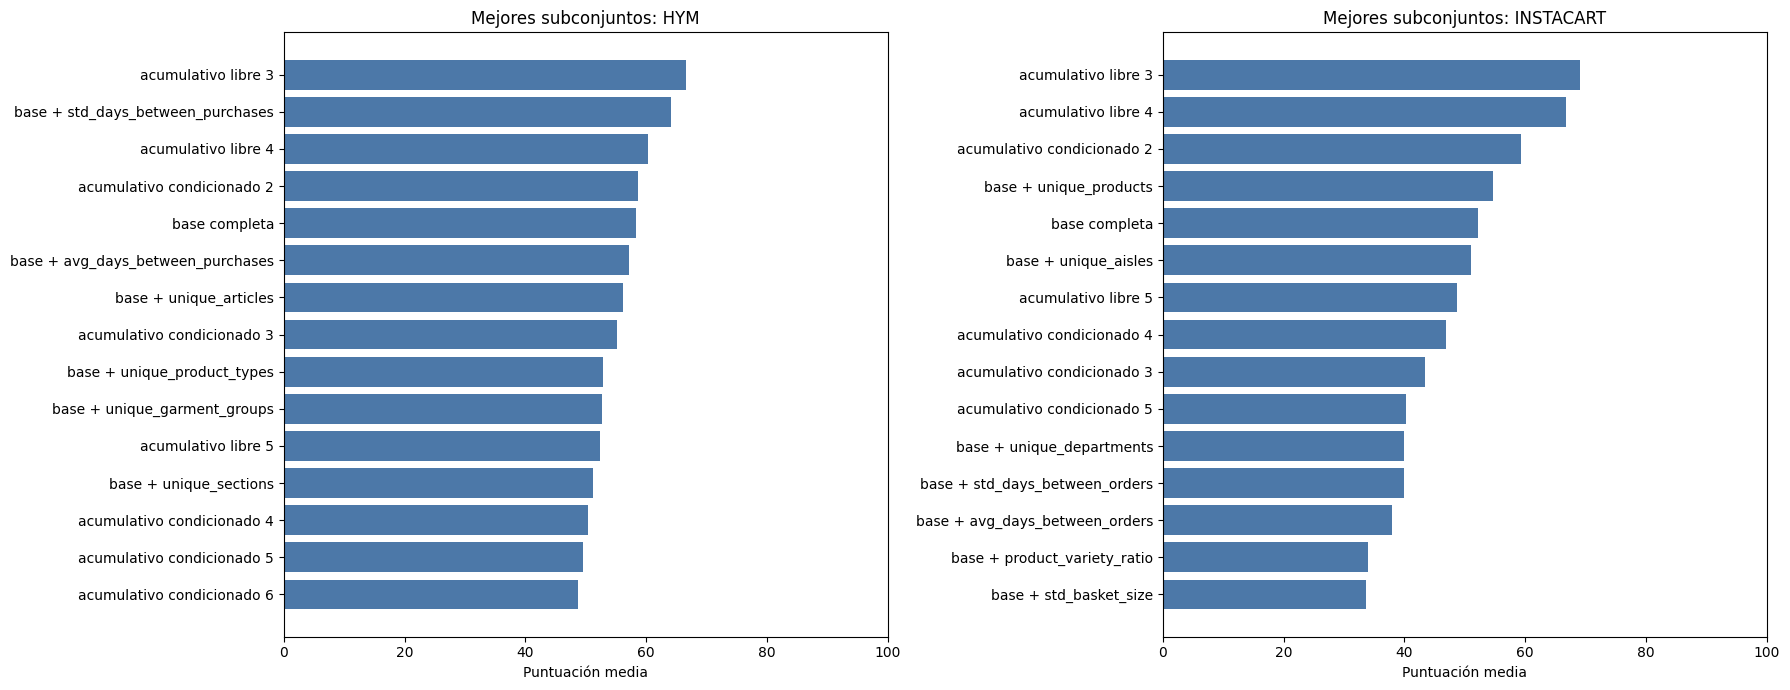

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, dataset in zip(axes, ["hym", "instacart"]):
    datos = (
        ranking_candidatos.loc[ranking_candidatos["dataset"] == dataset]
        .head(15)
        .sort_values("score")
    )
    ax.barh(datos["subset"], datos["score"], color="#4C78A8")
    ax.set_title(f"Mejores subconjuntos: {dataset.upper()}")
    ax.set_xlabel("Puntuación media")
    ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

## Guardado de resultados

In [8]:
resumen_completo.to_csv(
    RESULTS_DIR / "feature_selection_results.csv", index=False
)
recomendadas.to_csv(
    RESULTS_DIR / "recommended_features.csv", index=False
)
print("Resultados guardados en la carpeta results")

Resultados guardados en la carpeta results
